# The First Villain: Overfitting

Overfitting is not a quirk of linear models with too many columns. It has many faces, and it is
always waiting to ruin an attempt at prediction. This page collects a few examples — one in code,
two from history — so that you recognize it when you meet it somewhere new.

## Increasing complexity with polynomials

In the [previous section](practice_linear_models.ipynb) we made a model more complex by adding
more *variables*. But complexity can also grow while the number of variables stays at one.

Let's take 50 participants and look at the volume of the right middle temporal gyrus as a
function of age.

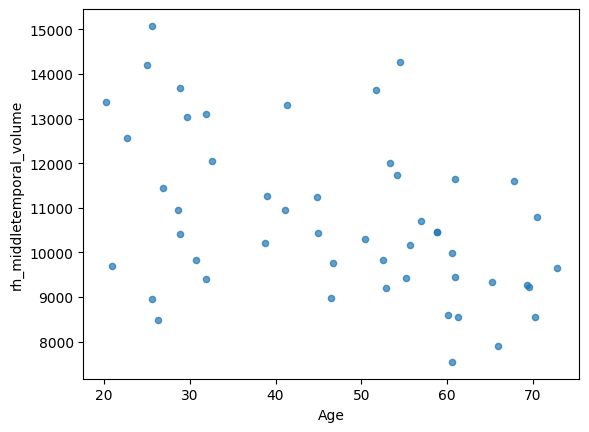

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

DATA_URL = "https://raw.githubusercontent.com/pni-lab/predmod_lecture/master/ex_data/IXI/ixi.csv"

ixi = pd.read_csv(DATA_URL).sample(frac=1, random_state=42).reset_index(drop=True)
df = ixi.iloc[:50].copy()

df.plot.scatter(x='Age', y='rh_middletemporal_volume', alpha=0.7)
plt.show()

A linear model of this is a straight line. But a linear model can also fit a *curve*: if we add
$x^2$ as an extra predictor we can capture a U-shape, with $x^3$ an S-shape, and so on. This is
still a linear model — linear in the coefficients — and it is fitted by exactly the same least
squares machinery. The degree of the polynomial is a dial that sets how wiggly the fitted curve
is allowed to be.

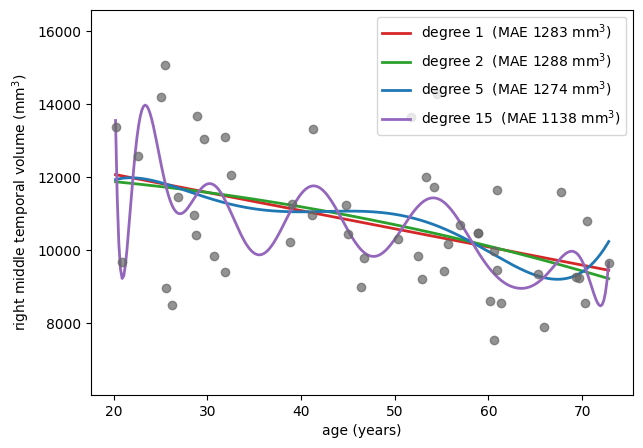

In [2]:
x = df['Age'].values
y = df['rh_middletemporal_volume'].values
x_grid = np.linspace(x.min(), x.max(), 300)

plt.figure(figsize=(7, 5))
plt.scatter(x, y, alpha=0.7, color='0.4', zorder=3)

for degree, color in zip([1, 2, 5, 15], ['#d62728', '#2ca02c', '#1f77b4', '#9467bd']):
    polynomial = np.polynomial.Polynomial.fit(x, y, deg=degree)
    residuals = y - polynomial(x)
    plt.plot(x_grid, polynomial(x_grid), color=color, lw=2,
             label=f'degree {degree}  (MAE {np.mean(np.abs(residuals)):.0f} mm$^3$)')

plt.ylim(y.min() - 1500, y.max() + 1500)
plt.xlabel('age (years)')
plt.ylabel('right middle temporal volume (mm$^3$)')
plt.legend()
plt.show()

The straight line says something simple and plausible: this region shrinks with age. The degree-2
curve says something slightly more elaborate. By degree 15 the curve is lurching up and down
between neighbouring participants, and its error on these 50 points is the smallest of the four —
which, after the previous page, should no longer impress us in the slightest.

Nobody believes that the volume of the middle temporal gyrus genuinely oscillates every few
years of age. The wiggles are not anatomy; they are the particular 50 people in this sample.

```{note}
Polynomials are useful in moderation. Adding a squared term is a standard and often
well-motivated way to let a linear model capture a curved relationship. The danger is not the
technique but the dial: each extra degree gives the model more freedom to bend towards the data at
hand, and at a small sample size even a second-order polynomial can already be fitting noise.
```

:::{admonition} Exercise 2.5
:class: tip, dropdown
Which degree looks reasonable to you? Now increase the sample size to 400 participants
(`ixi.iloc[:400]`) and re-run the cell. Does the degree-15 curve still lurch about?

:::{admonition} Solution
:class: note, dropdown
With 400 participants the high-degree curve is visibly tamer: it still wiggles at the edges,
where data is sparse, but it no longer chases individual points in the middle. More data does
not remove the capacity to overfit — it just means there is more signal to drown out the noise.
Sample size and model complexity always have to be considered together.
:::
:::

## Google Flu Trends

In 2008 Google set out to predict the severity of the coming influenza season from what people
search for. The idea was published, deployed as Google Flu Trends (GFT) — and then failed, and
failed spectacularly {cite:p}`butler2013google`, overshooting the peak of the 2013 US flu season
by 140%.

One reason was overfitting. With tens of millions of candidate search terms and only a hundred or
so weeks of influenza data to fit against, the model had far more ways to explain the training
period than there were meaningful patterns in it. It settled on terms that happened to move with
flu season in the training data — winter sports queries such as "high school basketball" — which
carried no information about influenza whatsoever.

The lesson generalizes directly to biomedical data, where "tens of thousands of candidate
features, a few hundred participants" is the normal state of affairs.

:::{seealso}
A readable account of what went wrong is
[here](https://www.wired.com/2015/10/can-learn-epic-failure-google-flu-trends/).
:::

## The Ptolemaic model of the solar system

The [Ptolemaic model](https://en.wikipedia.org/wiki/Geocentric_model#Ptolemaic_model) put the
Earth at the centre of the universe. In such a system the apparent motion of the planets can only
be reproduced with elaborate nested circular orbits — epicycles. Astronomers who wanted more
accurate predictions had to keep adding epicycles, and each addition did improve the fit to the
observations, until the whole construction became so convoluted that people began to doubt it.

:::{margin}
```{figure-md} ptolemy

<img src="Ptolemaic_system.png" alt="Diagram of the Ptolemaic system of nested circular orbits" width="200px">

The Ptolemaic system.
```
:::

Then Copernicus moved the centre to the sun, and Kepler made the orbits ellipses. Suddenly no
epicycles were needed at all: a far simpler model made far better predictions.

The take-home message is subtler than "simple models are better". The epicycles were not added
out of carelessness — they were forced by a wrong assumption about the structure of the problem.
With the right structure, the elaborate machinery simply
becomes unnecessary — so a large part of what we fight as "overfitting" is really the cost of
having the wrong model in the first place.

(Only a part, though. Even a perfectly specified model will overfit if it has many parameters and
few observations, simply because its coefficients are estimated from limited data.)

Unfortunately, essentially every model we use in science is misspecified. Which is why this book
exists.

## Occam's razor

[Occam's razor](https://en.wikipedia.org/wiki/Occam%27s_razor), the principle of parsimony, says
that when competing explanations account for the observations equally well, one should prefer the
one making the fewest assumptions.

Read through the lens of prediction, the razor stops being a philosophical preference and becomes
an empirical strategy: simpler models overfit less, and therefore predict better on new data,
even when a more complex model fits the existing data better. In
[chapter 4](../4_reducing_complexity/index.md) we will see how regularization turns Occam's razor
into an equation with a dial on it — one that decides, from the data itself, exactly how much
complexity to cut away.

But before we can tune complexity, we need to be able to *measure* whether a model predicts well.
That is the subject of [the next chapter](../3_cross_validation/index.md).